In [1]:
cd ..

/home/bhchen/LearnKalmanGain


In [8]:
import torch
import os
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

# =================== Configuration & Style ===================

MAIN_LINE_WIDTH = 2.0
X_LIM = (-0.5, 300) 
GRID_LS = "--"
GRID_ALPHA = 0.6
OUT_DIR = os.path.join("save", "figures")
os.makedirs(OUT_DIR, exist_ok=True)

# Fixed format: list of dicts with 'path' (str) and 'tags' (list of str)
experiment_configs = [
    {
        "path": "2026-02-01_00-29lorenz63_1.0_10_60_8192_pre_nll_wpf_ammd_joint_CorrTerms",
        "tags": ["CorrTerms", "pre_NLL", "MMD"]
    },
    {
        "path": "2026-02-01_00-31lorenz63_1.0_10_60_8192_nll_joint_CorrTerms",
        "tags": ["CorrTerms", "NLL"]
    },
    {
        "path": "2026-02-01_00-31lorenz63_1.0_10_60_8192_nll_joint_EtE-LRes",
        "tags": ["EtE", "NLL"]
    },
    {
        "path": "2026-02-01_00-31lorenz63_1.0_10_60_8192_nll_wpf_ed_joint_CorrTerms",
        "tags": ["CorrTerms", "NLL", "ED"]
    },
    {
        "path": "2026-02-01_00-31lorenz63_1.0_10_60_8192_nll_wpf_ed_joint_EtE-LRes",
        "tags": ["EtE", "NLL", "ED"]
    },
    {
        "path": "2026-02-01_00-31lorenz63_1.0_10_60_8192_pre_nll_joint_CorrTerms",
        "tags": ["CorrTerms", "pre_NLL"]
    },
    {
        "path": "2026-02-01_00-31lorenz63_1.0_10_60_8192_pre_nll_joint_EtE-LRes",
        "tags": ["EtE", "pre_NLL"]
    },
    {
        "path": "2026-02-01_00-31lorenz63_1.0_10_60_8192_pre_nll_wpf_ammd_joint_EtE-LRes",
        "tags": ["EtE", "pre_NLL", "MMD"]
    },
    {
        "path": "2026-02-01_00-31lorenz63_1.0_10_60_8192_pre_nll_wpf_ed_joint_CorrTerms",
        "tags": ["CorrTerms", "pre_NLL", "ED"]
    },
    {
        "path": "2026-02-01_00-31lorenz63_1.0_10_60_8192_pre_nll_wpf_ed_joint_EtE-LRes",
        "tags": ["EtE", "pre_NLL", "ED"]
    },
    {
        "path": "2026-02-01_00-32lorenz63_1.0_10_60_8192_es_joint_CorrTermscomp_ss",
        "tags": ["CorrTerms", "ES"]
    },
    {
        "path": "2026-02-01_00-32lorenz63_1.0_10_60_8192_es_joint_EtE-LRescomp_ss",
        "tags": ["EtE", "ES"]
    },
    {
        "path": "2026-02-01_00-32lorenz63_1.0_10_60_8192_nll_wpf_ammd_joint_CorrTerms",
        "tags": ["CorrTerms", "NLL", "MMD"]
    },
    {
        "path": "2026-02-01_00-32lorenz63_1.0_10_60_8192_nll_wpf_ammd_joint_EtE-LRes",
        "tags": ["EtE", "NLL", "MMD"]
    },
    {
        "path": "2026-02-01_00-41lorenz63_1.0_10_60_8192_nl2_joint_CorrTermscomp_ss",
        "tags": ["CorrTerms", "NL2"]
    },
    {
        "path": "2026-02-01_00-41lorenz63_1.0_10_60_8192_nl2_joint_EtE-LRescomp_ss",
        "tags": ["EtE", "NL2"]
    }
]

metrics_config = [
    {"key": 'mean_cov_diff', "ylabel": "Cov. Diff", "fname": "rcov_diff", "ylim": (0, 3.5)},
    {"key": 'mean_pf_rrmse', "ylabel": "PF RRMSE", "fname": "pf_rrmse", "ylim": (0, 0.1)}
]

def get_method_style(tags):
    """
    Determine color and linestyle based on method tags.
    """
    # 1. Determine Line Style
    ls = "--" if "CorrTerms" in tags else "-"
    
    # 2. Determine Color based on Loss + Regularizer combo
    if "pre_NLL" in tags:
        if "ED" in tags:
            color = "tab:brown"
        elif "MMD" in tags:
            color = "tab:pink"
        else:
            color = "tab:purple"
            
    elif "NLL" in tags:
        if "ED" in tags:
            color = "tab:red"
        elif "MMD" in tags:
            color = "tab:green"
        else:
            color = "tab:orange"
            
    elif "NL2" in tags:
        color = "tab:cyan"
        
    elif "ES" in tags:
        color = "tab:blue"
    else:
        color = "black"

    return {"color": color, "linestyle": ls}

# =================== UI Components ===================

all_tags = sorted(list(set(t for c in experiment_configs for t in c["tags"])))

tag_checks = [
    widgets.Checkbox(
        value=True, 
        description=tag, 
        style={'description_width': 'initial'}, 
        layout=widgets.Layout(width='auto', margin='0px 15px 0px 0px') 
    ) for tag in all_tags
]

save_check = widgets.Checkbox(
    value=False, 
    description="Save Figures (PDF)", 
    style={'description_width': 'initial'}
)
side_legend_check = widgets.Checkbox(
    value=True, 
    description="Show Side Legend", 
    style={'description_width': 'initial'}
)
btn_plot = widgets.Button(
    description="Generate Plots", 
    button_style='primary', 
    icon='area-chart'
)
output = widgets.Output()

def run_plotting(_):
    with output:
        clear_output(wait=True)
        # Get the set of currently selected tags from the UI
        selected_tags = set([chk.description for chk in tag_checks if chk.value])
        
        if not selected_tags:
            print("Please select at least one tag.")
            return

        # ------------------- UPDATED LOGIC HERE -------------------
        # Only include a configuration if ALL of its tags are present in the selected_tags set.
        # This uses the .issubset() method.
        # Example: If config has tags ['EtE', 'MMD'] and user unchecks 'MMD', 
        # issubset will be False, and the curve will not be shown.
        active_configs = [
            c for c in experiment_configs 
            if set(c["tags"]).issubset(selected_tags)
        ]
        # ----------------------------------------------------------
        
        handles, labels = [], []

        for metric in metrics_config:
            fig, ax = plt.subplots(figsize=(12, 6))
            
            for config in active_configs:
                # Construct file path
                file_path = os.path.join('save', 'Lorenz63_self_supervised', config["path"], 'training_records.pt')
                if not os.path.exists(file_path): 
                    continue

                data = torch.load(file_path, weights_only=True, map_location="cpu")
                curve = np.array(data.get(metric['key'], []))
                epochs = np.array(data.get('test_epochs', []))
                
                if len(curve) > 0:
                    name = "+".join(config["tags"])
                    style = get_method_style(config["tags"])
                    ln, = ax.plot(epochs, curve, label=name, lw=MAIN_LINE_WIDTH, **style)
                    
                    if metric == metrics_config[0]: # Collect handles once for the standalone legend
                        handles.append(ln)
                        labels.append(name)

            ax.set_title(f"Lorenz63 - {metric['ylabel']}", fontsize=16)
            ax.set_ylabel(metric['ylabel'], fontsize=14)
            ax.set_xlabel('Epoch', fontsize=14)
            ax.grid(True, ls=GRID_LS, alpha=GRID_ALPHA)
            ax.set_xlim(*X_LIM)
            if metric['ylim']: ax.set_ylim(*metric['ylim'])
            
            # Show Side Legend if toggle is on
            if side_legend_check.value:
                ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

            if save_check.value:
                save_path = os.path.join(OUT_DIR, f"lorenz63_{metric['fname']}.pdf")
                plt.savefig(save_path, format="pdf", bbox_inches="tight")
            
            plt.show()

        # Generate Standalone Horizontal Legend (Adaptive)
        if handles:
            n_items = len(handles)
            ncol = min(5, n_items) # Max 5 items per row
            nrow = int(np.ceil(n_items / ncol))
            
            # Dynamic height calculation
            fig_leg, ax_leg = plt.subplots(figsize=(10, 0.6 * nrow))
            ax_leg.axis('off')
            ax_leg.legend(handles, labels, loc='center', ncol=ncol, frameon=False)
            
            if save_check.value:
                plt.savefig(os.path.join(OUT_DIR, "legend_standalone.pdf"), bbox_inches="tight")
            plt.show()

# =================== Interactive UI Layout ===================

# Group tags into rows, with a maximum of 5 items per row
tag_rows = [widgets.HBox(tag_checks[i:i + 5]) for i in range(0, len(tag_checks), 5)]

# Assemble the Tags Section container
tags_header = widgets.HTML("<h4>Method Tags (Select to Filter)</h4>")
tags_container = widgets.VBox([tags_header] + tag_rows)

# Assemble the Control Section container
controls_header = widgets.HTML("<h4>Plotting Controls</h4>")
controls_hbox = widgets.HBox([save_check, side_legend_check, btn_plot])
controls_container = widgets.VBox([
    widgets.HTML("<hr>"), 
    controls_header, 
    controls_hbox
])

# Final Display Structure
ui = widgets.VBox([
    tags_container, 
    controls_container, 
    widgets.HTML("<br>"), 
    output
])

# Render the UI
display(ui)

# Bind the click event
btn_plot.on_click(run_plotting)

--- Processing Metric: mean_cov_diff ---
    Saved plot to save/figures/lorenz63_rcov_diff_1e-3.pdf


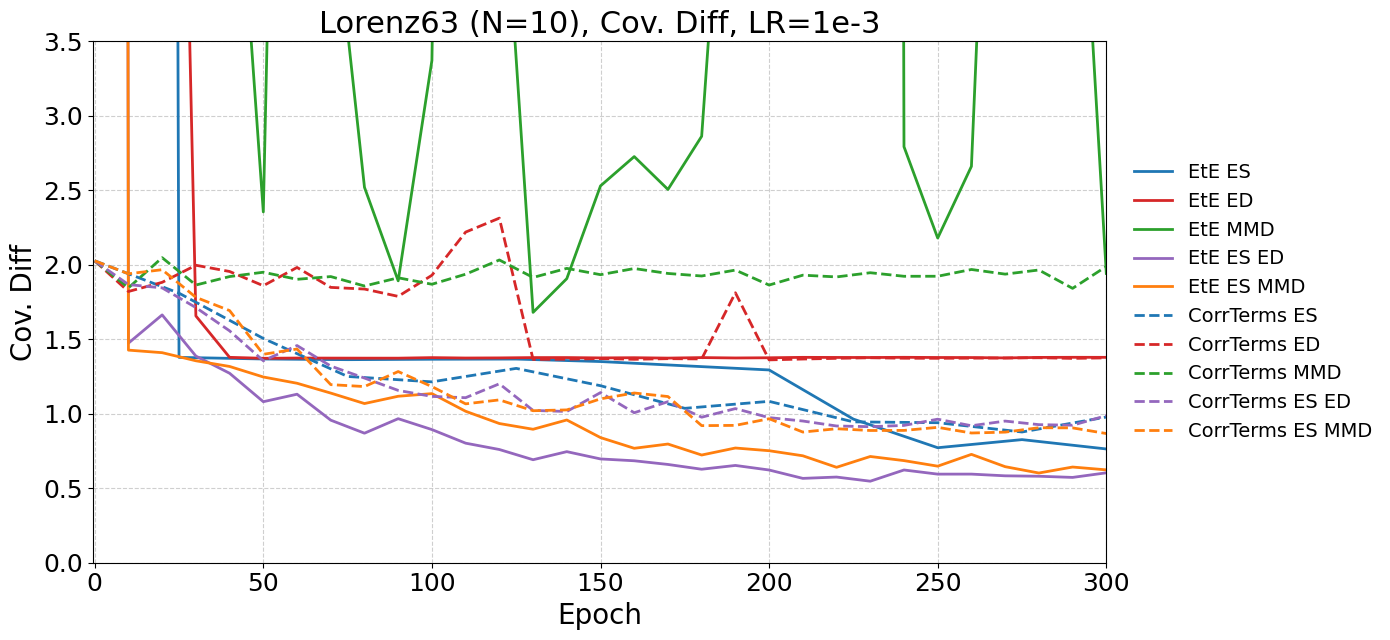

--- Processing Metric: mean_pf_rrmse ---
    Saved plot to save/figures/lorenz63_pf_rrmse_1e-3.pdf


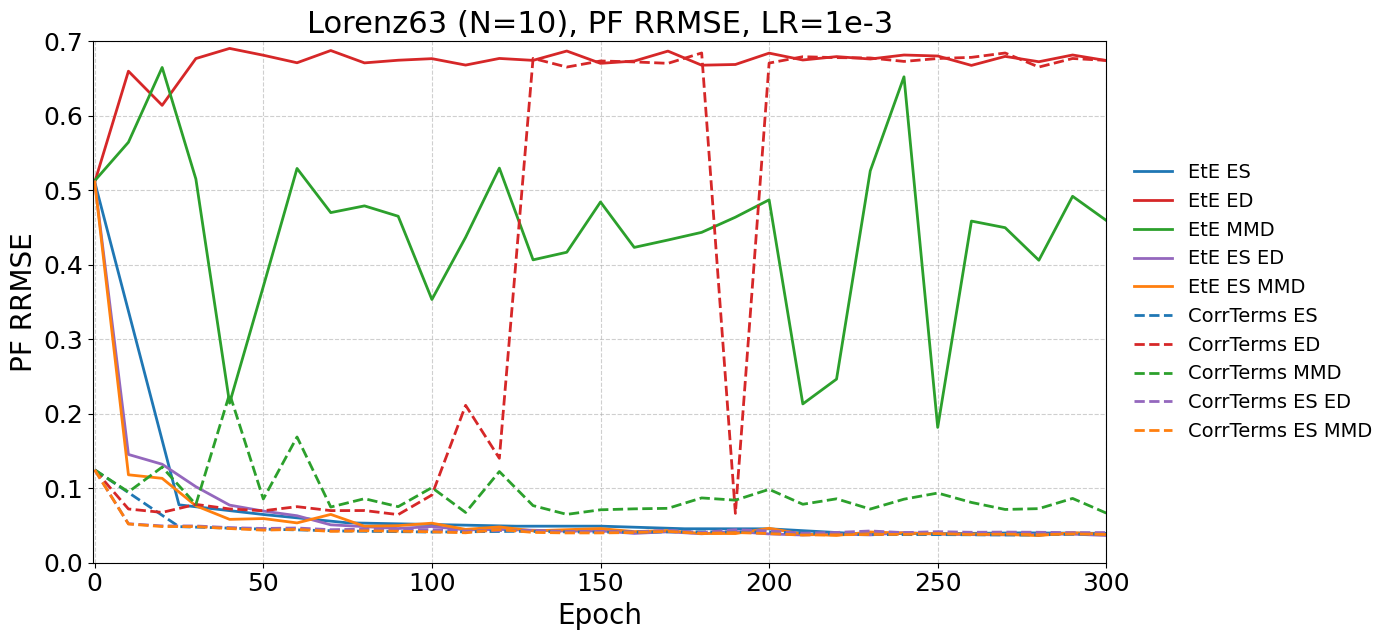

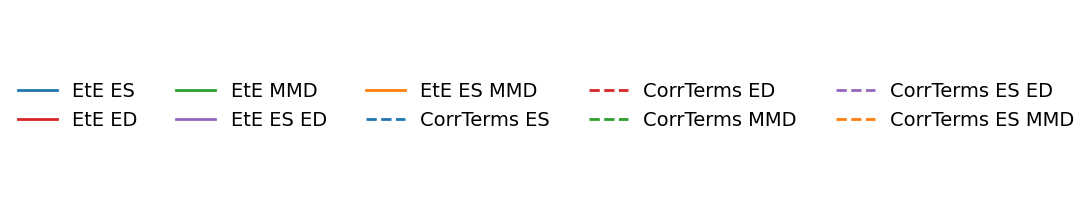

In [3]:
import torch
import os
import matplotlib.pyplot as plt
import numpy as np

# =================== Style & layout knobs ===================

SHOW_SIDE_LEGEND = True
FIGSIZE_MAIN = (14, 6.5) if SHOW_SIDE_LEGEND else (10, 6.5)
FIGSIZE_LEGEND = (10, 2.5) # Increased height for more items

MAIN_LINE_WIDTH = 2.0
X_LIM = (-0.5, 300) 
GRID_LS = "--"
GRID_ALPHA = 0.6

TITLE_FONTSIZE = 22
AXIS_LABEL_FONTSIZE = 20
TICK_FONTSIZE = 18
LEGEND_FONTSIZE = 14 

# =================== Data Configuration ===================

benchmark_data = {} # Empty for now as per your snippet

metrics_config = [
    {
        "key": 'mean_cov_diff',
        "ylabel": "Cov. Diff",
        "fname": "rcov_diff",
        "ylim": (0, 3.5) 
    },
    {
        "key": 'mean_pf_rrmse',
        "ylabel": "PF RRMSE",
        "fname": "pf_rrmse",
        "ylim": (0, 0.7) 
    }
]

lr_folder_map = {
    "1e-3": [
        "2025-12-25_15-10lorenz63_1.0_10_60_8192_es_joint_EtE-LRes",
        "2026-01-21_14-42lorenz63_1.0_10_60_8192_wpf_ed_joint_EtE-LRes",
        "2026-01-21_14-53lorenz63_1.0_10_60_8192_wpf_ammd_joint_EtE-LRes",
        "2026-01-21_19-39lorenz63_1.0_10_60_8192_es_wpf_ed_joint_EtE-LRes",
        "2026-01-21_19-39lorenz63_1.0_10_60_8192_es_wpf_ammd_joint_EtE-LRes",
        "2026-01-14_01-06lorenz63_1.0_10_60_8192_es_joint_CorrTerms",
        "2026-01-21_14-53lorenz63_1.0_10_60_8192_wpf_ed_joint_CorrTerms",
        "2026-01-21_14-53lorenz63_1.0_10_60_8192_wpf_ammd_joint_CorrTerms",
        "2026-01-21_19-39lorenz63_1.0_10_60_8192_es_wpf_ed_joint_CorrTerms",
        "2026-01-21_19-39lorenz63_1.0_10_60_8192_es_wpf_ammd_joint_CorrTerms",
    ],
}

method_names = ['EtE ES','EtE ED', 'EtE MMD', 'EtE ES ED', 'EtE ES MMD', 'CorrTerms ES', 'CorrTerms ED', 'CorrTerms MMD', 'CorrTerms ES ED', 'CorrTerms ES MMD']

lrs_to_plot = ["1e-3"] 
out_dir = os.path.join("save", "figures")
os.makedirs(out_dir, exist_ok=True)

# =================== Helper: Style Logic ===================

def get_method_style(name):
    """
    Determines color and linestyle based on method name semantics.
    Input: method name (str)
    Output: dict with 'color', 'linestyle'
    """
    # 1. Determine Line Style (Family)
    # EtE -> Solid
    # CorrTerms -> Dashed
    if "CorrTerms" in name:
        ls = "--"
    else:
        ls = "-"

    # 2. Determine Color (Variant)
    # Using Tab10 palette for high contrast
    # Check compound keys first (e.g., 'ES ED') to avoid partial match issues
    if "ES ED" in name:
        color = "tab:purple"
    elif "ES MMD" in name:
        color = "tab:orange"
    elif "ES" in name:
        color = "tab:blue"
    elif "ED" in name:
        color = "tab:red"
    elif "MMD" in name:
        color = "tab:green"
    else:
        color = "black"

    return {"color": color, "linestyle": ls}

# =================== Main Loops ===================

for metric in metrics_config:
    print(f"--- Processing Metric: {metric['key']} ---")
    
    for lr in lrs_to_plot:
        folder_names = lr_folder_map.get(lr, [])
        if not folder_names: continue

        fig, ax = plt.subplots(figsize=FIGSIZE_MAIN)
        title_str = f"Lorenz63 (N=10), {metric['ylabel']}, LR={lr}"
        ax.set_title(title_str, fontsize=TITLE_FONTSIZE)

        # 1. Plot Training Methods
        for i, folder_name in enumerate(folder_names):
            file_path = os.path.join('save', 'lorenz63_wpf', folder_name, 'training_records.pt')
            
            if not os.path.exists(file_path):
                print(f"    Missing file: {folder_name}")
                continue

            data = torch.load(file_path, weights_only=True)
            curve = np.array(data.get(metric['key'], []))
            epochs = np.array(data.get('test_epochs', []))
            
            name = method_names[i]
            style = get_method_style(name) # Get dynamic style

            if len(curve) > 0:
                ax.plot(epochs, curve, 
                        linewidth=MAIN_LINE_WIDTH, 
                        label=name,
                        color=style['color'],
                        linestyle=style['linestyle'])
            else:
                print(f"    Empty key {metric['key']} in {folder_name}")

        # 2. Benchmark Lines (if any)
        for b_name, b_values in benchmark_data.items():
            y_val = b_values.get(metric['key'])
            if y_val is not None:
                # ... (benchmark plotting code remains same) ...
                pass 

        # 3. Formatting
        ax.set_ylabel(metric['ylabel'], fontsize=AXIS_LABEL_FONTSIZE)
        ax.set_xlabel('Epoch', fontsize=AXIS_LABEL_FONTSIZE)
        ax.grid(True, which="both", linestyle=GRID_LS, alpha=GRID_ALPHA)
        ax.set_xlim(*X_LIM)
        if metric['ylim']:
            ax.set_ylim(*metric['ylim'])
        ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
        
        # 4. Side Legend 
        if SHOW_SIDE_LEGEND:
            ax.legend(
                loc='center left', 
                bbox_to_anchor=(1, 0.5), 
                fontsize=LEGEND_FONTSIZE,
                frameon=False,
                borderaxespad=1  # Add padding between plot and legend
            )

        save_path = os.path.join(out_dir, f"lorenz63_{metric['fname']}_{lr}.pdf")
        fig.tight_layout()
        fig.savefig(save_path, format="pdf", bbox_inches="tight")
        print(f"    Saved plot to {save_path}")
        plt.show(fig) 

# =================== Standalone Legend (Optional) ===================
# Only needed if you want a separate file for the legend
fig_legend, ax_legend = plt.subplots(figsize=FIGSIZE_LEGEND)
ax_legend.axis('off')
handles, labels = ax.get_legend_handles_labels()
# Organize handles if needed (e.g. sort by family)
ax_legend.legend(handles, labels, loc='center', ncol=5, frameon=False, fontsize=LEGEND_FONTSIZE)
plt.show(fig_legend)